In [1]:
from langgraph.graph import StateGraph , START,END
from typing import TypedDict , Literal
from pydantic import BaseModel,Field
from dotenv import load_dotenv
from langchain_groq import ChatGroq

In [2]:
!pip install langchain-groq

In [3]:
!pip install LangGraph


In [4]:
from dotenv import load_dotenv
load_dotenv()


True

In [5]:
import os
model = ChatGroq(api_key=os.getenv("GROQ_API_KEY")
                 ,temperature=0.0,
                 model = "openai/gpt-oss-120b")

In [6]:
class query(BaseModel):
    query_type: Literal["student policies",'hostel rules','placement guidelines','admission_faq','scholarship details']


In [7]:
structured_model= model.with_structured_output(query)

In [8]:
promt= "what are the admission rules"
ans = structured_model.invoke(promt)
print(ans)

query_type='admission_faq'


In [9]:
class review_state(TypedDict):
    response: str
    query_type : Literal["student policies",'hostel rules','placement guidelines','admission_faq','scholarship details']
    query : str


In [10]:
graph = StateGraph(review_state)


In [11]:
def check_query_type(state: review_state)->Literal["student policies",'hostel rules','placement guidelines','admission_faq','scholarship details']:
    query_type=model.with_structured_output(query)
    return review_state





In [12]:
def student_policies(state: review_state):
     pass


In [13]:
def scholarship(state: review_state):
    pass

In [14]:
def admission_faq(state: review_state):
    pass

In [15]:
def hostel_rules(state: review_state):
    pass

In [16]:
def placement_guidelines(state: review_state):
    pass


In [17]:

graph.add_node('hostel rules',hostel_rules)
graph.add_node('placement guidelines',placement_guidelines)

graph.add_node('admission faq',admission_faq)
graph.add_node('scholarship',scholarship)


In [18]:
graph.add_node('check query type',check_query_type)
graph.add_node('student policies',student_policies)

In [19]:
graph.add_edge(START,'check query type')
graph.add_conditional_edges(
    "check query type",
    check_query_type,
    {
     "student_policies":"student policies"
    ,'hostel_rules':'hostel rules'
    ,'placement_guidelines':'placement guidelines'
    ,'admission_faq':'admission faq',
    'scholarship details':'scholarship'
    }
)


In [20]:
graph.add_edge('student policies',END)
graph.add_edge('hostel rules',END)
graph.add_edge('placement guidelines',END)
graph.add_edge('admission faq',END)
graph.add_edge('scholarship',END)


In [21]:
graph.add_edge(START,"check query type")

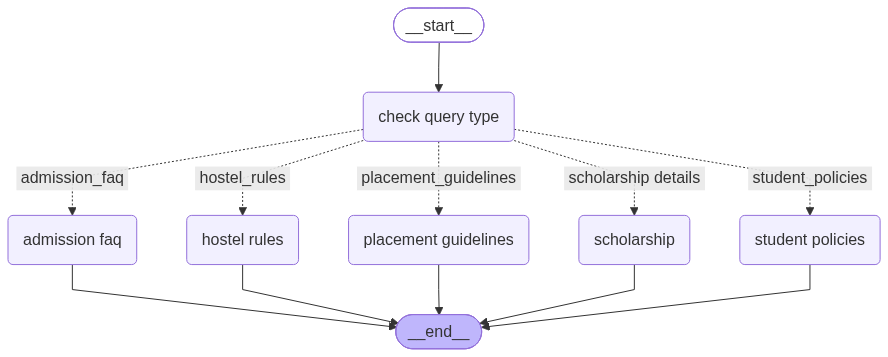

In [24]:
graph.compile()

In [23]:
print(workflow)